In [247]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from ISLP import load_data

In [248]:
# Load the dataset
data = pd.read_csv("MBA.csv")  # Update with the correct file path

#data['admission'] = data['admission'].replace({'Admit': 'Yes', 'Waitlist': '2', None: 'No'})
data['admission'] = data['admission'].replace({'Admit': 1, 'Waitlist': '2', None: 0})

# Preprocess the data (drop missing values or handle them accordingly)
data = data.dropna()

# Drop rows where 'admission' column equals 2
data = data[data['admission'] != '2']

In [249]:
# Define features (X) and target (y)
from ISLP.models import (ModelSpec as MS, summarize, poly)
X = data.drop(columns=['admission', 'application_id'])
# Assuming 'X' is your DataFrame
X = pd.get_dummies(X, drop_first=True)
X = MS(X).fit_transform(X)
y = data['admission']

In [250]:
# Split the data into training and testing sets
# Set a random seed for reproducibility
np.random.seed(88)
train_size = int(len(X) / 3)
train_indices = np.random.choice(len(X), train_size, replace=False)
test_indices = np.setdiff1d(np.arange(len(X)), train_indices)

X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

## My own logistic regression code

In [251]:
import numpy as np

# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Logistic Regression using IRLS
class LogisticRegressionIRLS:
    def __init__(self, tolerance=1e-6, max_iter=100):
        self.tolerance = tolerance
        self.max_iter = max_iter

    def fit(self, X_train, y_train):
        # Step 1: Initialize beta (weights) to zero
        self.beta = np.zeros(X_train.shape[1])
        
        # Convert g to binary y based on given conditions
        #y = np.where(g == 1, 1, 0)
        
        for iteration in range(self.max_iter):
            # Step 3: Compute p
            p = sigmoid(np.array(np.dot(X_train, self.beta), dtype=float))
            
            # Step 4: Compute diagonal matrix W
            W = np.diag(p * (1 - p))
            
            # Step 5: Compute z
            z = np.dot(X_train, self.beta) + np.dot(np.linalg.inv(W), (y_train - p))
            
            # Step 6: Update beta
            reg_param = 1e-10
            beta_new = np.dot(np.linalg.inv(np.dot(X_train.T, np.dot(W, X_train)) + reg_param * np.identity(X_train.shape[1])), np.dot(X_train.T, np.dot(W, z)))
            
            # Check for convergence
            if np.linalg.norm(beta_new - self.beta) < self.tolerance:
                self.beta = beta_new
                break

            # Update beta for the next iteration
            self.beta = beta_new

    def predict_proba(self, X_test):
        return sigmoid(np.array(np.dot(X_test, self.beta), dtype=float))

    def predict(self, X_test):
        probabilities = self.predict_proba(X_test)
        return [1 if p > 0.5 else 0 for p in probabilities]


# Initialize and train the model
model = LogisticRegressionIRLS(tolerance=1e-6, max_iter=100)
model.fit(X_train, y_train)

# Make predictions
predictions = np.array(model.predict(X_test))
probabilities = model.predict_proba(X_test)

#print("Predictions:", predictions)
print("Probabilities:", probabilities)
print("Model Coefficients (Beta):", model.beta)

Probabilities: [0.09939938 0.0100344  0.01268604 ... 0.01271401 0.03471586 0.01839356]
Model Coefficients (Beta): [-27.846575295262934 0.0 4.398203752270906 0.019078424286696143
 0.002460012929581052 -0.8882510759811644 -0.01982833400809244
 0.1077557582435825 -0.6615946625009224 -1.1519002556083293
 -0.6934205631389533 0.09673943653595317 -0.8152329464790089
 -0.7894994475231254 -0.16588058171612108 -1.1583597707964106
 -0.6588339907065137 -0.19940353102169261 -1.4058667812769068
 -0.32794206210165466 -0.9086647659670994 -1.0847919586128096
 -0.2514254173313972 0.4563917763951455 -0.07263299904232579]


In [252]:
len(predictions)
code_pred = np.array(predictions, dtype='<U3')

len(code_pred)
len(y_test)
y_test = np.where(y_test == 0, 'No', 'Yes')  # Convert 'No' to 0 and others to 1
code_pred = np.where(code_pred == '0', 'No', 'Yes')

In [254]:
# Calculate the confusion matrix
code_cm = confusion_matrix(y_test, code_pred)

# Convert the confusion matrix into a DataFrame for better readability with labels
code_cm_df = pd.DataFrame(code_cm, index=['True: No', 'True: Yes'], columns=['Pred: No', 'Pred: Yes'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(code_cm_df)

Confusion Matrix:
           Pred: No  Pred: Yes
True: No       2343         91
True: Yes       349         72


In [255]:
# Extract values from the confusion matrix
TN, FP, FN, TP = code_cm.ravel()

In [256]:
# Calculate False Positive Rate, False Negative Rate, True Positive Rate
false_positive_rate = FP / (FP + TN)  # FPR = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)  # FNR = FN / (FN + TP)
true_positive_rate = TP / (TP + FN)   # TPR (Recall) = TP / (TP + FN)
true_negative_rate = TN / (TN + FP)   # TNR = TN / (TN + FP)

print(f"False Positive Rate (FPR): {false_positive_rate:.2f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.2f}")
print(f"True Positive Rate (TPR): {true_positive_rate:.2f}")
print(f"True Negative Rate (TNR): {true_negative_rate:.2f}")

False Positive Rate (FPR): 0.04
False Negative Rate (FNR): 0.83
True Positive Rate (TPR): 0.17
True Negative Rate (TNR): 0.96


In [257]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, code_pred)
precision = precision_score(y_test, code_pred, pos_label='Yes')  # Adjust pos_label based on your dataset
recall = recall_score(y_test, code_pred, pos_label='Yes')
f1 = f1_score(y_test, code_pred, pos_label='Yes')
#Harmonic mean of precision and recall, balancing the two: f1=2*(precision*recall)/(precision+recall)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall (TPR): {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.85
Precision: 0.44
Recall (TPR): 0.17
F1 Score: 0.25


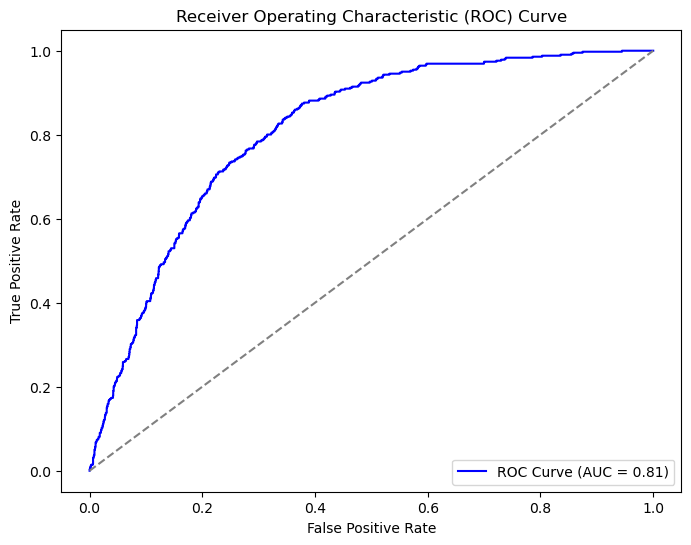

In [258]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, probabilities, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Using the Logistic Regression Package in Python

In [259]:
# Load the dataset
data = pd.read_csv("MBA.csv")  # Update with the correct file path

data['admission'] = data['admission'].replace({'Admit': 'Yes', 'Waitlist': '2', None: 'No'})
#data['admission'] = data['admission'].replace({'Admit': 1, 'Waitlist': '2', None: 0})

# Preprocess the data (drop missing values or handle them accordingly)
data = data.dropna()

# Drop rows where 'admission' column equals 2
data = data[data['admission'] != '2']

# Define features (X) and target (y)
from ISLP.models import (ModelSpec as MS, summarize, poly)
X = data.drop(columns=['admission', 'application_id'])
# Assuming 'X' is your DataFrame
X = pd.get_dummies(X, drop_first=True)
X = MS(X).fit_transform(X)
y = data['admission']

# Split the data into training and testing sets
# Set a random seed for reproducibility
np.random.seed(88)
train_size = int(len(X) / 3)
train_indices = np.random.choice(len(X), train_size, replace=False)
test_indices = np.setdiff1d(np.arange(len(X)), train_indices)

X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

In [260]:
### Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict probabilities on the test set
log_prob = log_reg.predict_proba(X_test)[:, 1]  # Get probabilities for the 'Yes' class
# Set prediction threshold at 0.5
log_pred = np.where(log_prob > 0.5, 'Yes', 'No')

In [261]:
# Calculate the confusion matrix
log_cm = confusion_matrix(y_test, log_pred)

# Convert the confusion matrix into a DataFrame for better readability with labels
log_cm_df = pd.DataFrame(log_cm, index=['True: No', 'True: Yes'], columns=['Pred: No', 'Pred: Yes'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(log_cm_df)


Confusion Matrix:
           Pred: No  Pred: Yes
True: No       2351         83
True: Yes       355         66


In [262]:
# Extract values from the confusion matrix
TN, FP, FN, TP = log_cm.ravel()

In [263]:
# Calculate False Positive Rate, False Negative Rate, True Positive Rate
false_positive_rate = FP / (FP + TN)  # FPR = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)  # FNR = FN / (FN + TP)
true_positive_rate = TP / (TP + FN)   # TPR (Recall) = TP / (TP + FN)
true_negative_rate = TN / (TN + FP)   # TNR = TN / (TN + FP)

print(f"False Positive Rate (FPR): {false_positive_rate:.2f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.2f}")
print(f"True Positive Rate (TPR): {true_positive_rate:.2f}")
print(f"True Negative Rate (TNR): {true_negative_rate:.2f}")

False Positive Rate (FPR): 0.03
False Negative Rate (FNR): 0.84
True Positive Rate (TPR): 0.16
True Negative Rate (TNR): 0.97


In [264]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, log_pred)
precision = precision_score(y_test, log_pred, pos_label='Yes')  # Adjust pos_label based on your dataset
recall = recall_score(y_test, log_pred, pos_label='Yes')
f1 = f1_score(y_test, log_pred, pos_label='Yes')
#Harmonic mean of precision and recall, balancing the two: f1=2*(precision*recall)/(precision+recall)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall (TPR): {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.85
Precision: 0.44
Recall (TPR): 0.16
F1 Score: 0.23


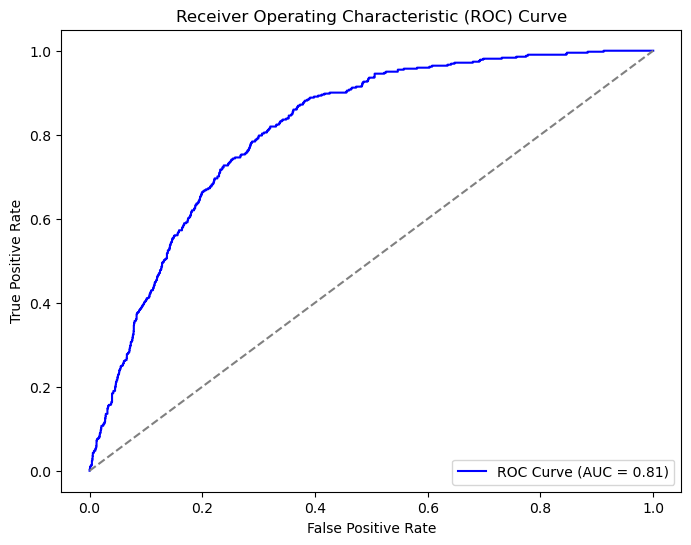

In [265]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, log_prob, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

The results from my code for logistic regression and the python logistic regression produce very similar output. The AUC are the sames for both (AUC=81). But they differ slightly on the recall and F1 score (Recall (TPR): 0.16, F1 Score: 0.23 for the logistic regressio and Recall (TPR): 0.17, F1 Score: 0.25 for my code). The two also have the same accuracy and precision. Overall, the two approaches are comparable in terms of their  model performance on the dataset.